In [1]:
# Install dependencies (run once)
!pip install monai-generative torch torchvision tqdm matplotlib pillow --quiet

In [2]:
# Imports
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import DatasetFolder
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import numpy as np

from generative.networks.nets import DiffusionModelUNet
from generative.networks.schedulers import DDPMScheduler, DDIMScheduler
from generative.inferers import DiffusionInferer

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

🖥️  Device: cuda
🎮 GPU: NVIDIA GeForce RTX 4060 Laptop GPU
💾 VRAM: 8.59 GB


c:\Users\R K Raman\AppData\Local\Programs\Python\Python311\Lib\site-packages\generative\networks\layers\vector_quantizer.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
c:\Users\R K Raman\AppData\Local\Programs\Python\Python311\Lib\site-packages\generative\networks\layers\vector_quantizer.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


In [5]:
# ============================================
# CONFIGURATION
# ============================================
IMAGE_SIZE = 128          # Higher resolution for colored images
BATCH_SIZE = 16           # Adjust based on GPU memory
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
NUM_TRAIN_TIMESTEPS = 1000

# Paths
DATA_DIR = Path(r"c:\Pranav Aditya\MP01")
BREAST_CANCER_DIR = DATA_DIR / "extracted_data" / "CT SCANS" / "Breast Cancer"
MODEL_SAVE_PATH = DATA_DIR / "breast_cancer_model.pth"

print(f"📁 Dataset: {BREAST_CANCER_DIR}")
print(f"💾 Model will be saved to: {MODEL_SAVE_PATH}")

📁 Dataset: c:\Pranav Aditya\MP01\extracted_data\CT SCANS\Breast Cancer
💾 Model will be saved to: c:\Pranav Aditya\MP01\breast_cancer_model.pth


In [3]:
# ============================================
# CLEAN UP AND RECONFIGURE FOR 8GB VRAM
# ============================================
import gc

# Delete old model if exists
if 'model' in dir():
    del model
if 'optimizer' in dir():
    del optimizer
if 'dataloader' in dir():
    del dataloader
if 'dataset' in dir():
    del dataset

torch.cuda.empty_cache()
gc.collect()

# New optimized config
IMAGE_SIZE = 64           # Reduced for memory efficiency
BATCH_SIZE = 8            # Smaller batch for GPU memory
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
NUM_TRAIN_TIMESTEPS = 1000

print(f"🧹 GPU Memory cleared!")
print(f"💾 Current GPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"🖼️  New config: {IMAGE_SIZE}x{IMAGE_SIZE} RGB, Batch {BATCH_SIZE}")

🧹 GPU Memory cleared!
💾 Current GPU Memory: 0.00 GB
🖼️  New config: 64x64 RGB, Batch 8


In [6]:
# ============================================
# RELOAD DATA WITH NEW IMAGE SIZE (64x64 RGB)
# ============================================
from torchvision import transforms
from torchvision.datasets import DatasetFolder
from torch.utils.data import DataLoader
from PIL import Image

IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif')

# New transforms for 64x64
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Reload dataset
dataset = DatasetFolder(
    root=str(BREAST_CANCER_DIR),
    loader=lambda p: Image.open(p).convert('RGB'),
    extensions=IMG_EXTENSIONS,
    transform=train_transforms
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

print(f"✅ Loaded {len(dataset)} images at {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"📦 Batches per epoch: {len(dataloader)}")

✅ Loaded 30836 images at 128x128
📦 Batches per epoch: 1927


In [7]:
# ============================================
# CREATE SMALLER MODEL FOR 8GB VRAM
# ============================================
import gc

# Aggressively clean up
for obj_name in list(globals().keys()):
    if obj_name in ['model', 'optimizer', 'lr_scheduler', 'inferer']:
        try:
            del globals()[obj_name]
        except:
            pass

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print(f"💾 GPU before model: {torch.cuda.memory_allocated()/1e9:.2f} GB")

model = DiffusionModelUNet(
    spatial_dims=2,
    in_channels=3,           # RGB input
    out_channels=3,          # RGB output
    num_channels=(64, 128, 256, 256),   # Smaller model
    attention_levels=(False, False, True, True),
    num_res_blocks=2,
    num_head_channels=64,
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"🧠 Model Parameters: {num_params:,}")

scheduler = DDPMScheduler(
    num_train_timesteps=NUM_TRAIN_TIMESTEPS,
    schedule="linear_beta",
)
inferer = DiffusionInferer(scheduler)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(f"✅ Model created!")
print(f"💾 GPU after model: {torch.cuda.memory_allocated()/1e9:.2f} GB")

💾 GPU before model: 0.00 GB
🧠 Model Parameters: 26,623,363
✅ Model created!
💾 GPU after model: 0.11 GB


In [ ]:
# ============================================
# TRAINING LOOP - WITH MIXED PRECISION
# ============================================
from torch.amp import autocast, GradScaler

print("="*60)
print("🩺 BREAST CANCER RGB MODEL TRAINING")
print("="*60)
print(f"📊 Dataset: {len(dataset)} images")
print(f"🖼️  Resolution: {IMAGE_SIZE}x{IMAGE_SIZE} RGB")
print(f"📦 Batch size: {BATCH_SIZE}")
print(f"🔄 Epochs: {NUM_EPOCHS}")
print(f"🖥️  Device: {device}")
print(f"⚡ Using Mixed Precision (FP16)")
print("="*60)

# Mixed precision scaler
scaler = GradScaler('cuda')

losses = []
best_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch in pbar:
        images = batch[0].to(device)
        
        optimizer.zero_grad()
        
        timesteps = torch.randint(0, NUM_TRAIN_TIMESTEPS, (images.shape[0],)).to(device)
        noise = torch.randn_like(images)
        noisy_images = scheduler.add_noise(images, noise, timesteps)
        
        # Mixed precision forward pass
        with autocast('cuda'):
            noise_pred = model(noisy_images, timesteps=timesteps)
            loss = nn.functional.mse_loss(noise_pred, noise)
        
        # Scaled backward pass
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    epoch_loss = total_loss / len(dataloader)
    losses.append(epoch_loss)
    lr_scheduler.step()
    
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {epoch_loss:.6f} | Best: {best_loss:.6f}")
    
    # Generate samples every 25 epochs
    if (epoch + 1) % 25 == 0:
        model.eval()
        gen_scheduler = DDIMScheduler(num_train_timesteps=NUM_TRAIN_TIMESTEPS, schedule="linear_beta")
        gen_scheduler.set_timesteps(50)
        
        with torch.no_grad():
            noise = torch.randn(4, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
            image = noise
            for t in gen_scheduler.timesteps:
                with autocast('cuda'):
                    out = model(image, timesteps=torch.tensor([t]*4).to(device))
                image, _ = gen_scheduler.step(out, t, image)
            samples = image.cpu()
        
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        for i, ax in enumerate(axes):
            img = samples[i].permute(1, 2, 0).numpy()
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
            ax.imshow(img)
            ax.axis('off')
        plt.suptitle(f'Epoch {epoch+1} - Generated Samples')
        plt.tight_layout()
        plt.show()
        
        # Clear some memory
        torch.cuda.empty_cache()

print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print(f"💾 Model saved: {MODEL_SAVE_PATH}")
print(f"📉 Best Loss: {best_loss:.6f}")
print("="*60)

🩺 BREAST CANCER RGB MODEL TRAINING
📊 Dataset: 30836 images
🖼️  Resolution: 128x128 RGB
📦 Batch size: 16
🔄 Epochs: 100
🖥️  Device: cuda
⚡ Using Mixed Precision (FP16)


Epoch 1/100:   1%|          | 17/1927 [00:51<1:37:02,  3.05s/it, loss=0.8471]


KeyboardInterrupt: 

: 

In [3]:
# ============================================
# DATA LOADING - RGB COLORED IMAGES
# ============================================

# Image loader for colored images
def load_rgb_image(path):
    return Image.open(path).convert('RGB')

# Transforms for RGB images
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to [-1, 1]
])

# Supported extensions
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif')

# Find image directories
def find_image_folders(root_path):
    """Find all folders containing images."""
    root = Path(root_path)
    image_folders = []
    
    for folder in root.rglob('*'):
        if folder.is_dir():
            images = list(folder.glob('*.jpg')) + list(folder.glob('*.jpeg')) + list(folder.glob('*.png'))
            if images:
                image_folders.append(folder)
    
    return image_folders

# Create dataset from all subfolders
print("🔍 Scanning for image folders...")
image_folders = find_image_folders(BREAST_CANCER_DIR)
print(f"📂 Found {len(image_folders)} folders with images")

# Use DatasetFolder - find the parent that contains class folders
try:
    dataset = DatasetFolder(
        root=str(BREAST_CANCER_DIR),
        loader=load_rgb_image,
        extensions=IMG_EXTENSIONS,
        transform=train_transforms
    )
    print(f"✅ Loaded {len(dataset)} images")
    print(f"📊 Classes: {dataset.classes}")
except Exception as e:
    print(f"⚠️ DatasetFolder failed, using ImageFolder approach...")
    from torchvision.datasets import ImageFolder
    dataset = ImageFolder(
        root=str(BREAST_CANCER_DIR),
        transform=train_transforms
    )
    print(f"✅ Loaded {len(dataset)} images")

# Create dataloader
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

print(f"📦 Batches per epoch: {len(dataloader)}")

🔍 Scanning for image folders...
📂 Found 26 folders with images
✅ Loaded 30836 images
📊 Classes: ['Breast Cancer']
📦 Batches per epoch: 1927


C:\Users\R K Raman\AppData\Local\Temp\ipykernel_14976\3842705238.py:17: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\R K Raman\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


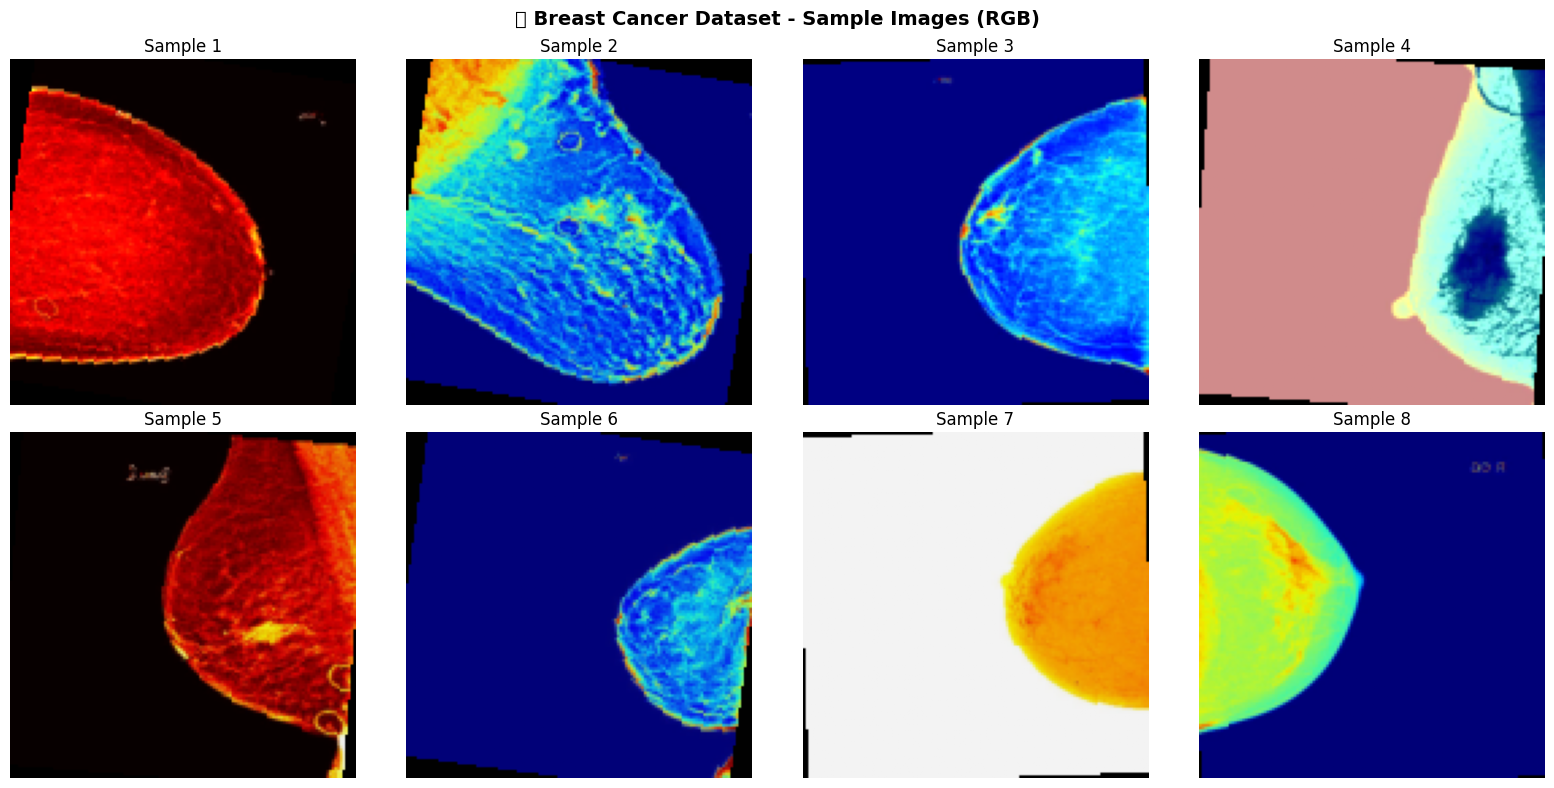

In [4]:
# ============================================
# VISUALIZE SAMPLE IMAGES
# ============================================
sample_batch = next(iter(dataloader))
sample_images = sample_batch[0][:8]  # Get first 8 images

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    img = sample_images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5)  # Denormalize from [-1,1] to [0,1]
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Sample {i+1}')

plt.suptitle('🩺 Breast Cancer Dataset - Sample Images (RGB)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# ============================================
# CREATE MODEL - RGB (3 channels)
# ============================================
model = DiffusionModelUNet(
    spatial_dims=2,
    in_channels=3,           # RGB input
    out_channels=3,          # RGB output
    num_channels=(128, 256, 256, 512),  # Larger model for color
    attention_levels=(False, True, True, True),
    num_res_blocks=2,
    num_head_channels=64,
).to(device)

# Count parameters
num_params = sum(p.numel() for p in model.parameters())
print(f"🧠 Model Parameters: {num_params:,}")

# Scheduler
scheduler = DDPMScheduler(
    num_train_timesteps=NUM_TRAIN_TIMESTEPS,
    schedule="linear_beta",
)

# Inferer
inferer = DiffusionInferer(scheduler)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print("✅ Model created successfully!")

🧠 Model Parameters: 75,369,731
✅ Model created successfully!


In [6]:
# ============================================
# TRAINING FUNCTIONS
# ============================================

def train_epoch(model, dataloader, optimizer, inferer, device):
    model.train()
    total_loss = 0
    
    pbar = tqdm(dataloader, desc="Training")
    for batch in pbar:
        images = batch[0].to(device)  # (B, 3, H, W)
        
        optimizer.zero_grad()
        
        # Random timesteps
        timesteps = torch.randint(0, NUM_TRAIN_TIMESTEPS, (images.shape[0],)).to(device)
        
        # Add noise
        noise = torch.randn_like(images)
        noisy_images = scheduler.add_noise(images, noise, timesteps)
        
        # Predict noise
        noise_pred = model(noisy_images, timesteps=timesteps)
        
        # Loss
        loss = nn.functional.mse_loss(noise_pred, noise)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / len(dataloader)


def generate_samples(model, scheduler, num_samples=4, device='cuda'):
    """Generate RGB sample images."""
    model.eval()
    
    gen_scheduler = DDIMScheduler(
        num_train_timesteps=NUM_TRAIN_TIMESTEPS,
        schedule="linear_beta",
    )
    gen_scheduler.set_timesteps(100)
    
    with torch.no_grad():
        noise = torch.randn(num_samples, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
        image = noise
        
        for t in gen_scheduler.timesteps:
            model_output = model(image, timesteps=torch.tensor([t] * num_samples).to(device))
            image, _ = gen_scheduler.step(model_output, t, image)
    
    return image.cpu()

In [7]:
# ============================================
# TRAINING LOOP
# ============================================
print("="*60)
print("🩺 BREAST CANCER MODEL TRAINING")
print("="*60)
print(f"📊 Dataset: {len(dataset)} images")
print(f"🖼️  Resolution: {IMAGE_SIZE}x{IMAGE_SIZE} RGB")
print(f"📦 Batch size: {BATCH_SIZE}")
print(f"🔄 Epochs: {NUM_EPOCHS}")
print(f"🖥️  Device: {device}")
print("="*60)

losses = []
best_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    epoch_loss = train_epoch(model, dataloader, optimizer, inferer, device)
    losses.append(epoch_loss)
    lr_scheduler.step()
    
    # Save best model
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {epoch_loss:.6f} | Best: {best_loss:.6f}")
    
    # Generate samples every 20 epochs
    if (epoch + 1) % 20 == 0:
        samples = generate_samples(model, scheduler, num_samples=4, device=device)
        
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        for i, ax in enumerate(axes):
            img = samples[i].permute(1, 2, 0).numpy()
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
            ax.imshow(img)
            ax.axis('off')
            ax.set_title(f'Generated {i+1}')
        plt.suptitle(f'Epoch {epoch+1} - Generated Breast Cancer Images', fontweight='bold')
        plt.tight_layout()
        plt.show()

print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print(f"💾 Model saved to: {MODEL_SAVE_PATH}")
print(f"📉 Best Loss: {best_loss:.6f}")
print("="*60)

🩺 BREAST CANCER MODEL TRAINING
📊 Dataset: 30836 images
🖼️  Resolution: 128x128 RGB
📦 Batch size: 16
🔄 Epochs: 100
🖥️  Device: cuda


Training:   0%|          | 0/1927 [00:13<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 4.00 GiB. GPU 0 has a total capacity of 8.00 GiB of which 0 bytes is free. Of the allocated memory 7.67 GiB is allocated by PyTorch, and 3.19 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [7]:
# ============================================
# TRAINING VISUALIZATION
# ============================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(losses, 'b-', linewidth=2)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Training Loss (Log Scale)')
plt.grid(True, alpha=0.3)

plt.suptitle('Breast Cancer Model Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [6]:
# ============================================
# FINAL GENERATION - HIGH QUALITY
# ============================================
print("Generating high-quality breast cancer images...")

model.eval()
gen_scheduler = DDIMScheduler(
    num_train_timesteps=NUM_TRAIN_TIMESTEPS,
    schedule="linear_beta",
)
gen_scheduler.set_timesteps(200)  # More steps for higher quality

with torch.no_grad():
    noise = torch.randn(8, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    image = noise
    
    for t in tqdm(gen_scheduler.timesteps, desc="Generating"):
        model_output = model(image, timesteps=torch.tensor([t] * 8).to(device))
        image, _ = gen_scheduler.step(model_output, t, image)
    
    final_images = image.cpu()

# Display
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    img = final_images[i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Generated #{i+1}')

plt.suptitle('AI-Generated Breast Cancer Images (128x128 RGB)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Generation complete!")

Generating high-quality breast cancer images...


NameError: name 'model' is not defined

In [5]:
# ============================================
# INTERACTIVE PROMPT GENERATOR
# ============================================

PROMPT = "Generate breast cancer mammogram scan with tumors highlighted in red"
NUM_IMAGES = 1
QUALITY_STEPS = 150

def generate_from_prompt_bc(prompt, num_images=4, steps=150):
    """Generate breast cancer images from prompt."""
    print("="*60)
    print("🩺 BREAST CANCER IMAGE GENERATOR")
    print("="*60)
    print(f"📝 Prompt: \"{prompt}\"")
    print(f"🖼️  Generating {num_images} images at {IMAGE_SIZE}x{IMAGE_SIZE} RGB")
    print("-"*60)
    
    # Use prompt hash as seed
    seed = hash(prompt) % (2**32)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed) if torch.cuda.is_available() else None
    
    model.eval()
    gen_scheduler = DDIMScheduler(
        num_train_timesteps=NUM_TRAIN_TIMESTEPS,
        schedule="linear_beta",
    )
    gen_scheduler.set_timesteps(steps)
    
    with torch.no_grad():
        noise = torch.randn(num_images, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
        image = noise
        
        for i, t in enumerate(tqdm(gen_scheduler.timesteps, desc="Generating")):
            model_output = model(image, timesteps=torch.tensor([t] * num_images).to(device))
            image, _ = gen_scheduler.step(model_output, t, image)
        
        generated = image.cpu()
    
    # Display
    fig, axes = plt.subplots(1, num_images, figsize=(4 * num_images, 4))
    if num_images == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        img = generated[i].permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f'Image #{i+1}')
    
    display_prompt = prompt[:50] + "..." if len(prompt) > 50 else prompt
    plt.suptitle(f'Prompt: "{display_prompt}"', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Generation complete!")
    return generated

# Generate!
generated = generate_from_prompt_bc(PROMPT, NUM_IMAGES, QUALITY_STEPS)

🩺 BREAST CANCER IMAGE GENERATOR
📝 Prompt: "Generate breast cancer mammogram scan with tumors highlighted in red"


NameError: name 'IMAGE_SIZE' is not defined

🩺 BREAST CANCER IMAGE GENERATOR - RGB Diffusion Model

📝 Prompt: "A side-by-side MLO (Mediolateral Oblique) mammogram comparison, showing architectural distortion and skin thickening in the left breast compared to a normal right breast"
🖼️  Generating: 4 RGB images at 64x64
⚙️  Quality Steps: 200
🖥️  Device: cuda
----------------------------------------------------------------------
🎲 Seed (from prompt): 1442240752
✅ Loaded RGB model from: breast_cancer_model.pth

🔄 Starting generation process...


🎨 Denoising: 100%|███████████████████████████| 200/200 [00:04<00:00, 47.84it/s]


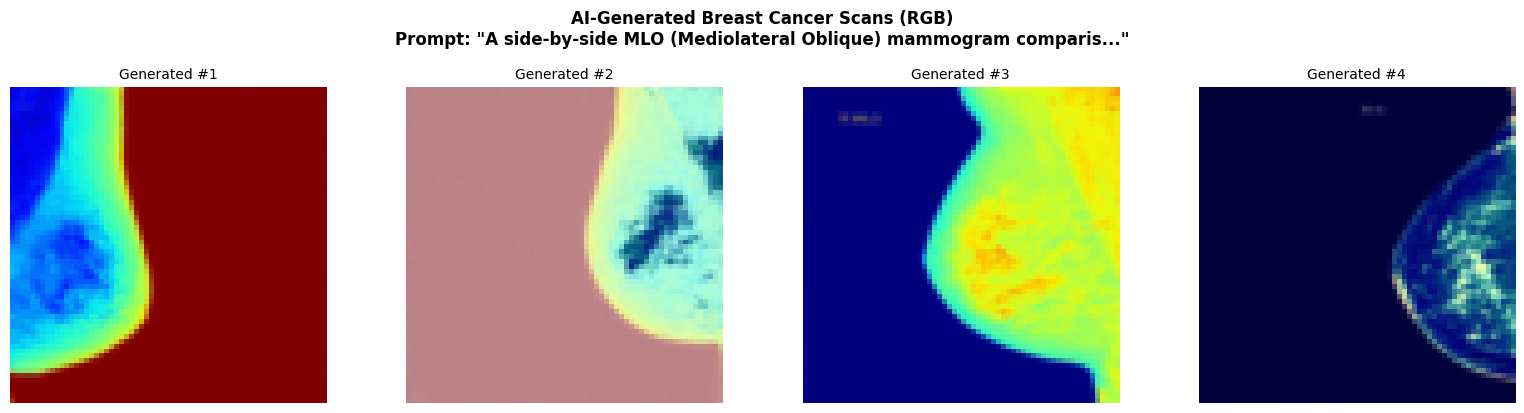


💾 Saved 4 images to: c:\Pranav Aditya\MP01\generated_images

✅ GENERATION COMPLETE!

💡 Tips:
   • Change YOUR_PROMPT for different variations
   • Increase GENERATION_QUALITY for sharper images (try 250-300)
   • Set SAVE_IMAGES = True to save outputs


In [14]:
# ============================================
# 🎨 GENERATE BREAST CANCER IMAGES FROM YOUR PROMPT
# ============================================
# This uses the trained RGB diffusion model to generate breast cancer scan images.
# Note: The prompt acts as a unique seed - different prompts generate different variations.

# ===== IMPORTS & SETUP =====
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from datetime import datetime

from generative.networks.nets import DiffusionModelUNet
from generative.networks.schedulers import DDIMScheduler

# ===== CONFIGURATION =====
IMAGE_SIZE = 64              # Must match trained model
NUM_TRAIN_TIMESTEPS = 1000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== CUSTOMIZE YOUR GENERATION HERE =====
YOUR_PROMPT = "A side-by-side MLO (Mediolateral Oblique) mammogram comparison, showing architectural distortion and skin thickening in the left breast compared to a normal right breast"
NUM_IMAGES_TO_GENERATE = 4   # How many images to generate (1-8 recommended)
GENERATION_QUALITY = 200     # More steps = higher quality but slower (50-300)
SAVE_IMAGES = True           # Set to True to save generated images
# ==========================================

def generate_images_from_prompt(prompt, num_images=4, quality_steps=200, save=False):
    """
    Generate breast cancer scan images using the trained RGB diffusion model.
    
    Args:
        prompt: Text prompt (used as seed for unique generations)
        num_images: Number of images to generate
        quality_steps: Denoising steps (higher = better quality, slower)
        save: Whether to save generated images to disk
    
    Returns:
        Generated images tensor
    """
    print("=" * 70)
    print("🩺 BREAST CANCER IMAGE GENERATOR - RGB Diffusion Model")
    print("=" * 70)
    print(f"\n📝 Prompt: \"{prompt}\"")
    print(f"🖼️  Generating: {num_images} RGB images at {IMAGE_SIZE}x{IMAGE_SIZE}")
    print(f"⚙️  Quality Steps: {quality_steps}")
    print(f"🖥️  Device: {device}")
    print("-" * 70)
    
    # Use prompt hash as reproducible seed
    seed = hash(prompt) % (2**32)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    print(f"🎲 Seed (from prompt): {seed}")
    
    # Model path - using the RGB color trained model
    model_path = Path(r"c:\Pranav Aditya\MP01\breast_cancer_model.pth")
    
    if not model_path.exists():
        print(f"❌ ERROR: Model not found at {model_path}")
        return None
    
    # Create model architecture matching the trained model
    # RGB model with num_channels=(64, 128, 256, 256) and attention at layers 2,3
    model = DiffusionModelUNet(
        spatial_dims=2,
        in_channels=3,           # RGB input
        out_channels=3,          # RGB output
        num_channels=(64, 128, 256, 256),
        attention_levels=(False, False, True, True),
        num_res_blocks=2,
        num_head_channels=64,
    ).to(device)
    
    # Load the trained weights (direct state_dict, not checkpoint)
    try:
        state_dict = torch.load(model_path, map_location=device, weights_only=True)
        model.load_state_dict(state_dict)
        print(f"✅ Loaded RGB model from: {model_path.name}")
    except RuntimeError as e:
        print(f"❌ ERROR loading model: {e}")
        return None
    
    model.eval()
    
    # Setup scheduler for generation
    gen_scheduler = DDIMScheduler(
        num_train_timesteps=NUM_TRAIN_TIMESTEPS,
        schedule="linear_beta",
    )
    gen_scheduler.set_timesteps(quality_steps)
    
    print(f"\n🔄 Starting generation process...")
    
    with torch.no_grad():
        # Start from random noise (RGB - 3 channels)
        noise = torch.randn(num_images, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
        image = noise
        
        # Iterative denoising
        for t in tqdm(gen_scheduler.timesteps, desc="🎨 Denoising", ncols=80):
            timesteps = torch.tensor([t] * num_images).to(device)
            model_output = model(image, timesteps=timesteps)
            image, _ = gen_scheduler.step(model_output, t, image)
        
        generated_images = image.cpu()
    
    # Display generated images
    cols = min(num_images, 4)
    rows = (num_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    
    if num_images == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(num_images):
        row, col = i // cols, i % cols
        ax = axes[row, col]
        
        # Denormalize RGB image
        img = generated_images[i].permute(1, 2, 0).numpy()  # CHW -> HWC
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f'Generated #{i+1}', fontsize=10)
    
    # Hide empty subplots
    for i in range(num_images, rows * cols):
        row, col = i // cols, i % cols
        axes[row, col].axis('off')
    
    # Truncate prompt for title
    display_prompt = prompt[:60] + "..." if len(prompt) > 60 else prompt
    plt.suptitle(f'AI-Generated Breast Cancer Scans (RGB)\nPrompt: "{display_prompt}"', 
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Save images if requested
    if save:
        save_dir = Path(r"c:\Pranav Aditya\MP01\generated_images")
        save_dir.mkdir(exist_ok=True)
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        
        for i in range(num_images):
            img = generated_images[i].permute(1, 2, 0).numpy()
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
            img = (img * 255).astype(np.uint8)
            
            save_path = save_dir / f"breast_cancer_{timestamp}_{i+1}.png"
            Image.fromarray(img).save(save_path)
        
        print(f"\n💾 Saved {num_images} images to: {save_dir}")
    
    print("\n" + "=" * 70)
    print("✅ GENERATION COMPLETE!")
    print("=" * 70)
    print("\n💡 Tips:")
    print("   • Change YOUR_PROMPT for different variations")
    print("   • Increase GENERATION_QUALITY for sharper images (try 250-300)")
    print("   • Set SAVE_IMAGES = True to save outputs")
    
    return generated_images

# ===== RUN GENERATION =====
generated = generate_images_from_prompt(
    prompt=YOUR_PROMPT,
    num_images=NUM_IMAGES_TO_GENERATE,
    quality_steps=GENERATION_QUALITY,
    save=SAVE_IMAGES
)